Dataset Shape: (29531, 16)
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  


C:\Users\junction pc\AppData\Local\Temp\ipykernel_16184\296181064.py:31: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')



🔥 Accuracy: 0.8169967834772304

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.76      0.80       364
           1       0.81      0.83      0.82      1936
           2       0.69      0.69      0.69       627
           3       0.86      0.86      0.86      2094
           4       0.81      0.79      0.80       282
           5       0.80      0.78      0.79       604

    accuracy                           0.82      5907
   macro avg       0.80      0.79      0.79      5907
weighted avg       0.82      0.82      0.82      5907



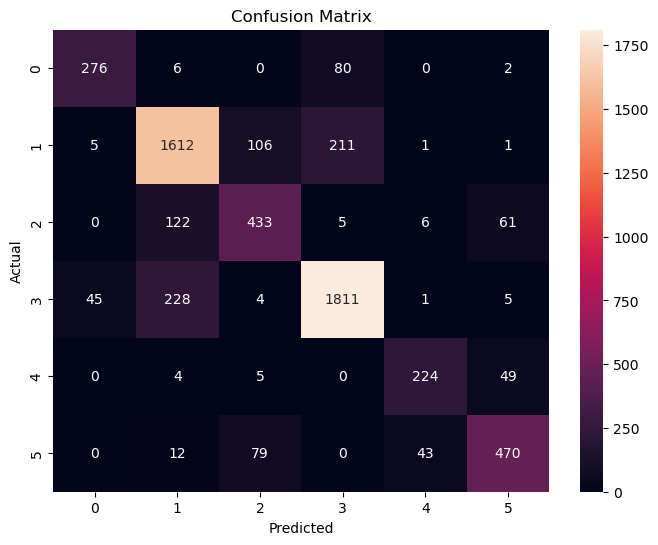


📌 Feature Importance:
PM2.5: 0.3381
PM10: 0.1453
NO2: 0.0631
CO: 0.1618
SO2: 0.0576
O3: 0.0654
NO: 0.0641
NOx: 0.0554
NH3: 0.0493

✅ Model saved successfully!

🔮 Predicted AQI Category: Moderate


In [1]:
# ================================
# 🔹 IMPORTS
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ================================
# 🔹 LOAD DATA
# ================================
df = pd.read_csv("city_day.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ================================
# 🔹 DATA CLEANING (IMPROVED)
# ================================
# 🔥 Added 3 more important features
df = df[['PM2.5','PM10','NO2','CO','SO2','O3','NO','NOx','NH3','AQI_Bucket']]

# 🔥 Better missing value handling (time-series)
df = df.fillna(method='ffill').fillna(method='bfill')

# Drop any remaining null target
df.dropna(subset=['AQI_Bucket'], inplace=True)

# ================================
# 🔹 ENCODING TARGET
# ================================
le = LabelEncoder()
df['AQI_Bucket'] = le.fit_transform(df['AQI_Bucket'])

# ================================
# 🔹 FEATURES & TARGET
# ================================
X = df[['PM2.5','PM10','NO2','CO','SO2','O3','NO','NOx','NH3']]
y = df['AQI_Bucket']

# ================================
# 🔹 FEATURE SCALING
# ================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================================
# 🔹 TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ================================
# 🔹 MODEL (IMPROVED)
# ================================
model = RandomForestClassifier(
    n_estimators=150,          # 🔥 better accuracy
    max_depth=None,            # 🔥 no limit = better learning
    min_samples_split=5,
    class_weight='balanced',   # 🔥 improves class 0
    random_state=42,
    n_jobs=-1
)

# 🔥 TRAIN MODEL
model.fit(X_train, y_train)

# ================================
# 🔹 PREDICTIONS
# ================================
y_pred = model.predict(X_test)

# ================================
# 🔹 PERFORMANCE METRICS
# ================================
accuracy = accuracy_score(y_test, y_pred)
print("\n🔥 Accuracy:", accuracy)

print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

# ================================
# 🔹 CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# 🔹 FEATURE IMPORTANCE
# ================================
importances = model.feature_importances_
features = X.columns

print("\n📌 Feature Importance:")
for f, imp in zip(features, importances):
    print(f"{f}: {round(imp,4)}")

# ================================
# 🔹 SAVE MODEL (SMALL SIZE)
# ================================
joblib.dump(model, "aqi_model.pkl", compress=5)   # 🔥 compressed
pickle.dump(le, open("label_encoder.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("\n✅ Model saved successfully!")

# ================================
# 🔹 TEST INPUT
# ================================
pm25, pm10, no2, co, so2, o3, no, nox, nh3 = 80, 120, 40, 1.2, 10, 30, 20, 35, 15

input_data = pd.DataFrame(
    [[pm25, pm10, no2, co, so2, o3, no, nox, nh3]],
    columns=['PM2.5','PM10','NO2','CO','SO2','O3','NO','NOx','NH3']
)

# Scale input
input_scaled = scaler.transform(input_data)

prediction = model.predict(input_scaled)
result = le.inverse_transform(prediction)

print("\n🔮 Predicted AQI Category:", result[0])

In [2]:
import requests
print("requests installed successfully")

requests installed successfully


In [4]:
API_KEY = "YOUR_API_KEY"

def get_live_aqi(lat, lon):
    url = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={lat}&lon={lon}&appid={API_KEY}"
    
    response = requests.get(url)
    data = response.json()
    
    aqi = data['list'][0]['main']['aqi']
    components = data['list'][0]['components']
    
    return aqi, components

In [5]:
lat = 23.2599   # Bhopal
lon = 77.4126

C:\Users\junction pc\AppData\Local\Temp\ipykernel_13768\3654909038.py:25: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


Accuracy: 0.819366852886406
              precision    recall  f1-score   support

           0       0.87      0.74      0.80       364
           1       0.81      0.84      0.82      1936
           2       0.72      0.67      0.69       627
           3       0.85      0.87      0.86      2094
           4       0.83      0.77      0.80       282
           5       0.79      0.79      0.79       604

    accuracy                           0.82      5907
   macro avg       0.81      0.78      0.80      5907
weighted avg       0.82      0.82      0.82      5907



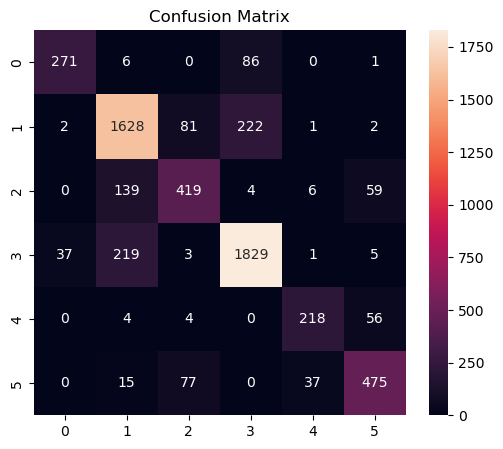

Model Saved Successfully!
Live AQI: 3
Pollutants: {'co': 119.3, 'no': 0.07, 'no2': 0.83, 'o3': 93.68, 'so2': 1.33, 'pm2_5': 30.55, 'pm10': 98.68, 'nh3': 5.8}


In [4]:
# ================================
# 🔹 IMPORTS
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import requests

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ================================
# 🔹 LOAD DATA
# ================================
df = pd.read_csv("city_day.csv")

# ================================
# 🔹 DATA CLEANING
# ================================
df = df[['PM2.5','PM10','NO2','CO','SO2','O3','NO','NOx','NH3','AQI_Bucket']]
df = df.fillna(method='ffill').fillna(method='bfill')
df.dropna(subset=['AQI_Bucket'], inplace=True)

# ================================
# 🔹 ENCODING
# ================================
le = LabelEncoder()
df['AQI_Bucket'] = le.fit_transform(df['AQI_Bucket'])

# ================================
# 🔹 FEATURES & TARGET
# ================================
X = df[['PM2.5','PM10','NO2','CO','SO2','O3','NO','NOx','NH3']]
y = df['AQI_Bucket']

# ================================
# 🔹 SCALING
# ================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================================
# 🔹 TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ================================
# 🔹 MODEL TRAINING
# ================================
model = RandomForestClassifier(
    n_estimators=150,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# ================================
# 🔹 PREDICTION & EVALUATION
# ================================
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ================================
# 🔹 CONFUSION MATRIX
# ================================
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# ================================
# 🔹 SAVE MODEL
# ================================
joblib.dump(model, "aqi_model.pkl")
joblib.dump(le, "label_encoder.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully!")

# ================================
# 🔹 LIVE AQI FUNCTION (SLR GAP FIX)
# ================================


import requests

API_KEY = "510d6cfb3fd4f328566b5ffa4cb3a6fa"

def get_live_aqi(lat, lon):
    url = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={lat}&lon={lon}&appid={API_KEY}"
    
    response = requests.get(url)
    data = response.json()

    if "list" not in data:
        print("API Error:", data)
        return None, None

    aqi = data['list'][0]['main']['aqi']
    components = data['list'][0]['components']
    
    return aqi, components

# ================================
# 🔹 TEST LIVE AQI
# ================================
lat = 23.2599   # Bhopal
lon = 77.4126

aqi, comp = get_live_aqi(lat, lon)

print("Live AQI:", aqi)
print("Pollutants:", comp)

In [2]:
import requests

API_KEY = "510d6cfb3fd4f328566b5ffa4cb3a6fa"

url = "http://api.openweathermap.org/data/2.5/air_pollution?lat=23.2599&lon=77.4126&appid=" + API_KEY

response = requests.get(url)

print(response.status_code)
print(response.text)

200
{"coord":{"lon":77.4126,"lat":23.2599},"list":[{"main":{"aqi":3},"components":{"co":119.3,"no":0.07,"no2":0.83,"o3":93.68,"so2":1.33,"pm2_5":30.55,"pm10":98.68,"nh3":5.8},"dt":1777715760}]}
